# 06 — Whole-ROI Kinetic Model Fitting

This notebook fits DCE-MRI pharmacokinetic models to a whole-ROI mean concentration curve.

Instead of fitting each voxel independently, the signal across all ROI voxels is pooled
into a single mean curve and the kinetic model is fit to that curve.

**Contents**
1. Setup and data loading
2. AIF inspection
3. ROI aggregation — signal vs concentration space comparison
4. Model fitting — TCXM and GKM without delay
5. Model fitting with AIF time delay — grid search
6. Model fitting with AIF time delay — continuous optimisation
7. Cost comparison — no delay vs grid vs continuous
8. Multi-ROI fitting (if segmentation available)

**When to use ROI fitting vs voxelwise fitting**
- ROI fitting: low SNR data, quick sanity check, heterogeneity analysis
- Voxelwise fitting: high SNR, spatial parameter maps needed

## 1. Setup and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from dce_mri.config import (
    AcquisitionConfig, SubjectConfig,
    FittingConfig, RoiFittingConfig,
    AifConfig
)

from dce_mri.kinetic_models import TCXM, GKM, tcxm_ct_analytic, gkm_ct
from dce_mri.signal_models import (
    signal_to_concentration, concentration_to_signal, shift_aif,extract_aif
)
from dce_mri.fitting_roi import (
    fit_roi,
    fit_roi_with_delay_grid,
    fit_roi_with_delay_continuous,
    fit_multi_roi,
    _aggregate_roi_signal,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Option A: use synthetic data (default — no files needed) ──────────
USE_SYNTHETIC = False   # set False to load real data below

acq     = AcquisitionConfig(TR=3.64, FA=10.0, r1=3.8,nbase=slice(0,2))
subject = SubjectConfig("test", T10=1530.0, B1=1.0)
cfg     = FittingConfig(n_lhs=200, n_top=10)

if USE_SYNTHETIC:
    # synthetic gamma-variate AIF with 30s baseline
    t   = np.linspace(0, 300, 90)
    t_b = t - 30.0
    aif = np.clip(((t_b/15)**4) * np.exp(-4*(t_b/15 - 1)), 0, None)
    aif[:9] = 0.0
    aif /= aif.max()

    # synthetic 4x4x4 volume — all voxels same signal
    # TODO: replace with real data loading
    S0 = 1000
    true_tau    = 8.4          # seconds
    shifted_aif = shift_aif(aif, true_tau, t, acq)
    Ct_true     = gkm_ct(GKM.p0, t, shifted_aif)
    sig_1d      = concentration_to_signal(Ct_true, acq, subject.T10,
                                           subject.B1, S0)
    sig_4d      = np.tile(sig_1d, (4, 4, 4, 1))
    mask        = np.ones((4, 4, 4), dtype=bool)
    seg_vol     = np.ones((4, 4, 4), dtype=int)  # single ROI label=1

    print(f"Synthetic data: {sig_4d.shape} volume, {mask.sum()} masked voxels")
    print(f"True params (TCXM): {TCXM.p0}")
    print(f"True tau: {true_tau} s")
    # --- noise settings ---
    snr_aif = 20
    snr_sig = 20    
    # --- signal noise ---
    sig_noise_std = S0 / snr_sig
    sig_4d_noisy = sig_4d + np.random.normal(0, sig_noise_std, size=sig_4d.shape)
    sig_4d_noisy = np.clip(sig_4d_noisy, 0, None)
    sig_4d = sig_4d_noisy
else:
    # ── Option B: load real data ──────────────────────────────────────
    #  edit these for each subject/dataset you load 
    from dce_mri.volume import load_nifti_canonical
    from dce_mri.io import load_aif
    
    DCE_PATH  = "/mnt/winshare/Labspace/Projects/fastMRIbreast/FMB_34spf_PCA_NII/FMB056/NIfTI/MGRASP_temptv_FMB056_lambda_0_001.nii.gz"
    AIF_PATH  = "/mnt/winshare/Labspace/Projects/fastMRIbreast/Lesion_nii_Files/Lesions_nii/FMB056ROI/ROI/56_Aorta_RotOrtho_6.nii"
    MASK_PATH = "/mnt/winshare/Labspace/Projects/fastMRIbreast/Lesion_nii_Files/Lesions_nii/FMB056ROI/ROI/56_Lesion 3_RotOrtho_6.nii"
    
    subject = SubjectConfig(
        subject_id         = "FMB056",
        T10                = 1530.0,
        B1                 = 1.0,
        dce_path_override  = DCE_PATH,
        aif_path_override   = AIF_PATH,
        mask_path_override  = MASK_PATH,
    )
    
    sig_4d, ref_img = load_nifti_canonical(subject.dce_path)

    # Time parameters
    nspoke    = 288    # total spokes across the whole scan
    scantime  = 150     # total scan duration, seconds
    spoke_res = 34       # spokes per frame
    
    dt = scantime * spoke_res / nspoke
    t = (np.arange(sig_4d.shape[-1])) * dt
    
    # load masks — binary ROI
    mask_aif,_      = load_nifti_canonical(subject.aif_path)
    aif_ROI         = mask_aif.astype(bool)
    mask_data, _ = load_nifti_canonical(subject.mask_path)
    lesion_ROI   = mask_data.astype(bool)
    
    # optional: load segmentation for multi-ROI fitting
    # seg_vol, _ = load_nifti_canonical(subject.seg_path)

    print(f"Loaded: {sig_4d.shape} volume, {lesion_ROI.sum()} tumor voxels, {aif_ROI.sum()} aif voxels")


Loaded: (320, 320, 192, 8) volume, 441 tumor voxels, 198 aif voxels


# 2. ROI inspection

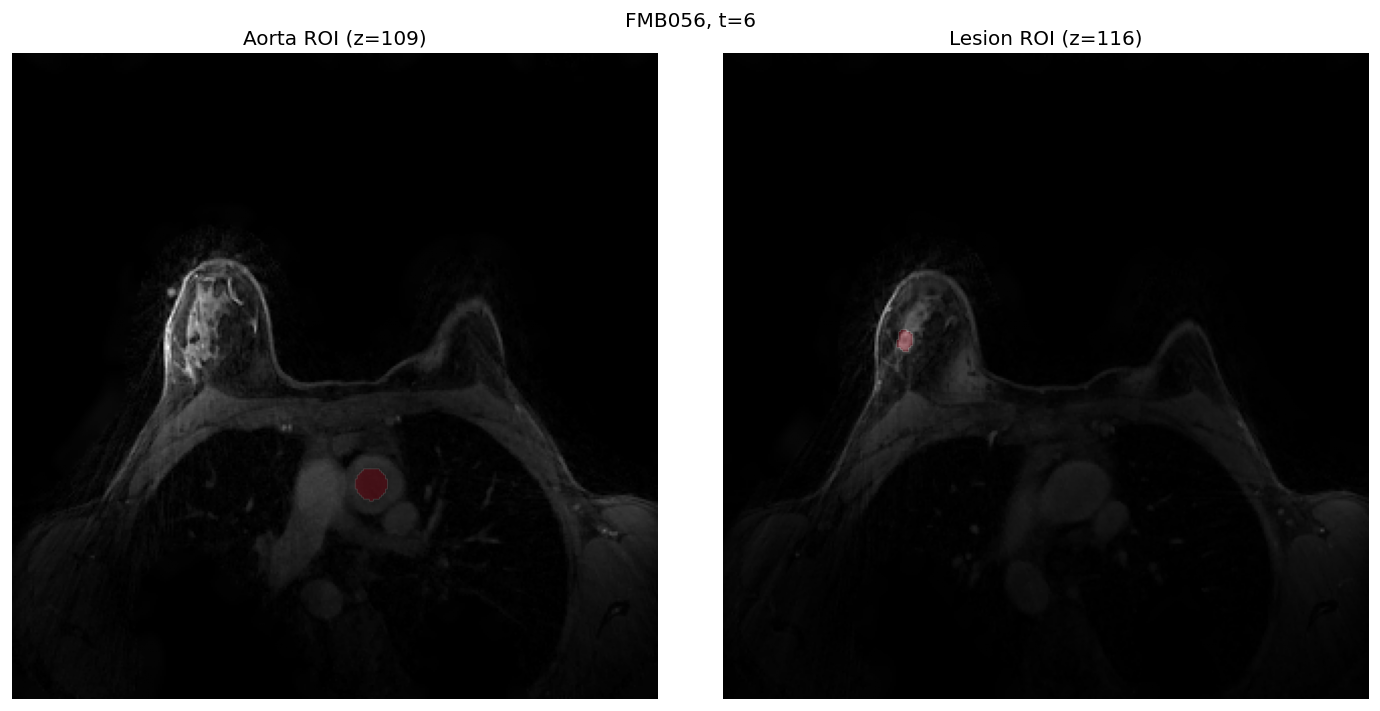

In [3]:
aif_idx = 109 
lesion_idx =116
time_idx = 6
    
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
img_aif = sig_4d[:, :, aif_idx, time_idx]
img_lesion = sig_4d[:, :, lesion_idx, time_idx]
  
axes[0].imshow(img_aif.T, cmap="gray", origin="lower")
axes[0].imshow(aif_ROI[:,:,aif_idx].T,cmap="Reds", alpha= 0.5 * aif_ROI[:,:,aif_idx].T ,origin="lower")
axes[0].set_title(f"Aorta ROI (z={aif_idx})")
axes[0].axis("off")

axes[1].imshow(img_lesion.T,cmap="gray", origin="lower")
axes[1].imshow(lesion_ROI[:,:,lesion_idx].T,cmap="Reds",alpha=0.5 * lesion_ROI[:,:,lesion_idx].T ,origin="lower")
axes[1].set_title(f"Lesion ROI (z={lesion_idx})")
axes[1].axis("off")
    
plt.suptitle(f"{subject.subject_id}, t={time_idx}")
plt.tight_layout()
plt.show()

## 2. AIF inspection

AIF signal range : [10.0, 49.6]
AIF plasma range : [-0.0041, 2.8549] mM


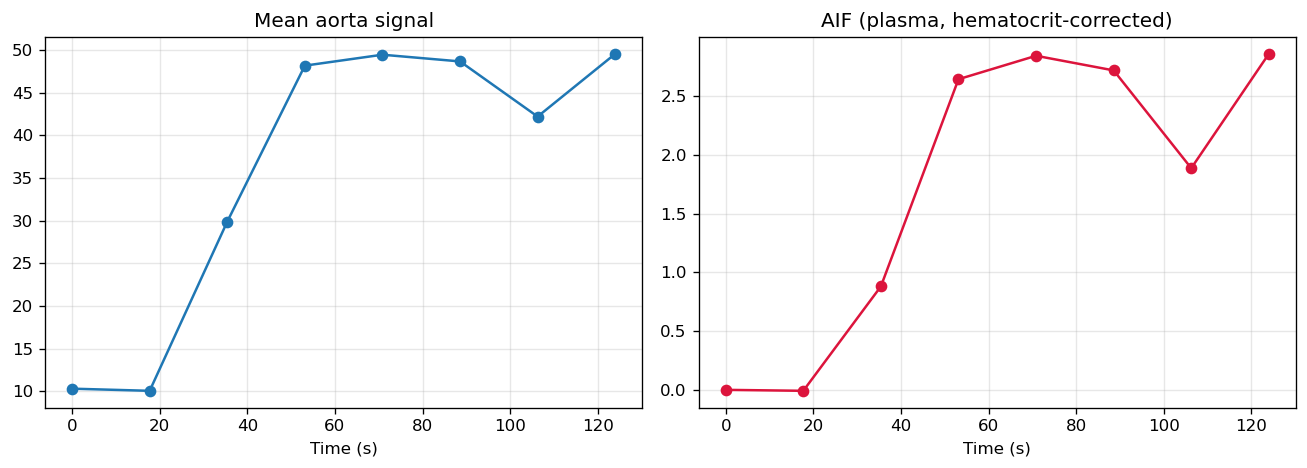

AIF peak time  : 124.0 s
AIF peak value : 2.8549 mM
AIF baseline   : 0.000007 mM


In [4]:
from dce_mri.config import AifConfig
from dce_mri.signal_models import extract_aif

aif_cfg = AifConfig(
    T10        = 1664.0,
    hematocrit = 0.45,
    top_frac   = 1.0,
    nbase      = slice(0, 2),
)

aif, aif_signal = extract_aif(sig_4d, aif_ROI, acq, aif_cfg, B1=subject.B1)

print(f"AIF signal range : [{aif_signal.min():.1f}, {aif_signal.max():.1f}]")
print(f"AIF plasma range : [{aif.min():.4f}, {aif.max():.4f}] mM")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, aif_signal, 'o-')
axes[0].set_title("Mean aorta signal")
axes[0].set_xlabel("Time (s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, aif, 'o-', color='crimson')
axes[1].set_title("AIF (plasma, hematocrit-corrected)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"AIF peak time  : {t[np.argmax(aif)]:.1f} s")
print(f"AIF peak value : {aif.max():.4f} mM")
print(f"AIF baseline   : {aif[acq.nbase].mean():.6f} mM")

## 3. ROI aggregation — signal vs concentration space

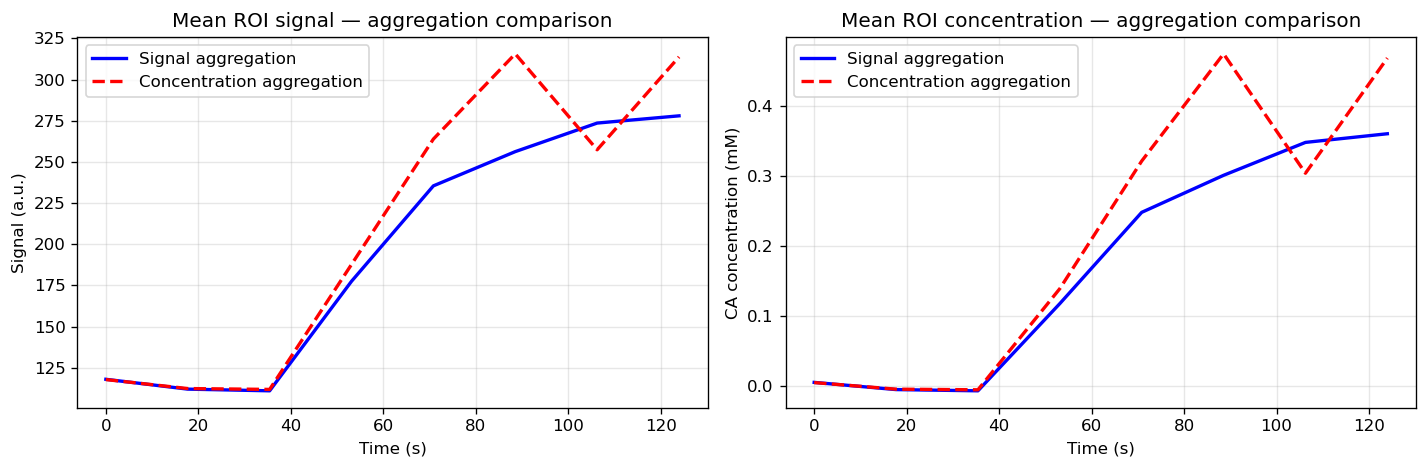

Signal aggregation   : 441 voxels
  Ct range: [-0.0069, 0.3606] mM
  St range: [111.1, 278.0] a.u.
Concentration aggregation: 441 voxels
  Ct range: [-0.0054, 0.4748] mM
  St range: [111.9, 315.6] a.u.
Max Ct difference (sig vs conc): 0.173635 mM


In [5]:
roi_cfg_sig  = RoiFittingConfig(average_space='signal')
roi_cfg_conc = RoiFittingConfig(average_space='concentration')

Ct_sig,  n_sig,  St_sig  = _aggregate_roi_signal(
    sig_4d, lesion_ROI, acq, subject, roi_cfg_sig
)
Ct_conc, n_conc, St_conc = _aggregate_roi_signal(
    sig_4d, lesion_ROI, acq, subject, roi_cfg_conc
)

St_conc = concentration_to_signal(
    Ct_conc,           # Ct from concentration-aggregation
    acq,
    T10=subject.T10,
    B1=subject.B1,
    S0=St_sig[acq.nbase].mean()   # baseline signal scale
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# signal space
axes[0].plot(t, St_sig,  'b-', lw=2, label='Signal aggregation')
axes[0].plot(t, St_conc, 'r--', lw=2, label='Concentration aggregation')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Signal (a.u.)')
axes[0].set_title('Mean ROI signal — aggregation comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# concentration space
axes[1].plot(t, Ct_sig,  'b-', lw=2, label='Signal aggregation')
axes[1].plot(t, Ct_conc, 'r--', lw=2, label='Concentration aggregation')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('CA concentration (mM)')
axes[1].set_title('Mean ROI concentration — aggregation comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Signal aggregation   : {n_sig} voxels")
print(f"  Ct range: [{Ct_sig.min():.4f}, {Ct_sig.max():.4f}] mM")
print(f"  St range: [{St_sig.min():.1f}, {St_sig.max():.1f}] a.u.")
print(f"Concentration aggregation: {n_conc} voxels")
print(f"  Ct range: [{Ct_conc.min():.4f}, {Ct_conc.max():.4f}] mM")
print(f"  St range: [{St_conc.min():.1f}, {St_conc.max():.1f}] a.u.")
print(f"Max Ct difference (sig vs conc): "
      f"{np.abs(Ct_sig - Ct_conc).max():.6f} mM")

## 4. Model fitting — TCXM and GKM without delay

In [6]:
roi_cfg = RoiFittingConfig(average_space='signal')

print("Fitting TCXM ...")
result_tcxm = fit_roi(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg, seed=0
)

print("Fitting GKM ...")
result_gkm = fit_roi(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg, seed=0
)

print("\n── TCXM results ──────────────────────────────────")
print(f"  success : {result_tcxm.success}")
print(f"  cost    : {result_tcxm.cost:.4e}")
for name, val in zip(TCXM.param_names, result_tcxm.params):
    print(f"  {name:8s}: {val:.5f}")

print("\n── GKM results ───────────────────────────────────")
print(f"  success : {result_gkm.success}")
print(f"  cost    : {result_gkm.cost:.4e}")
for name, val in zip(GKM.param_names, result_gkm.params):
    print(f"  {name:8s}: {val:.5f}")

Fitting TCXM ...
Fitting GKM ...

── TCXM results ──────────────────────────────────
  success : True
  cost    : 1.6125e-03
  ve      : 0.00010
  vp      : 0.17355
  fp      : 0.00375
  ps      : 0.02812

── GKM results ───────────────────────────────────
  success : True
  cost    : 4.6396e-02
  Ktrans  : 0.03333
  ve      : 0.50000
  vp      : 0.07229


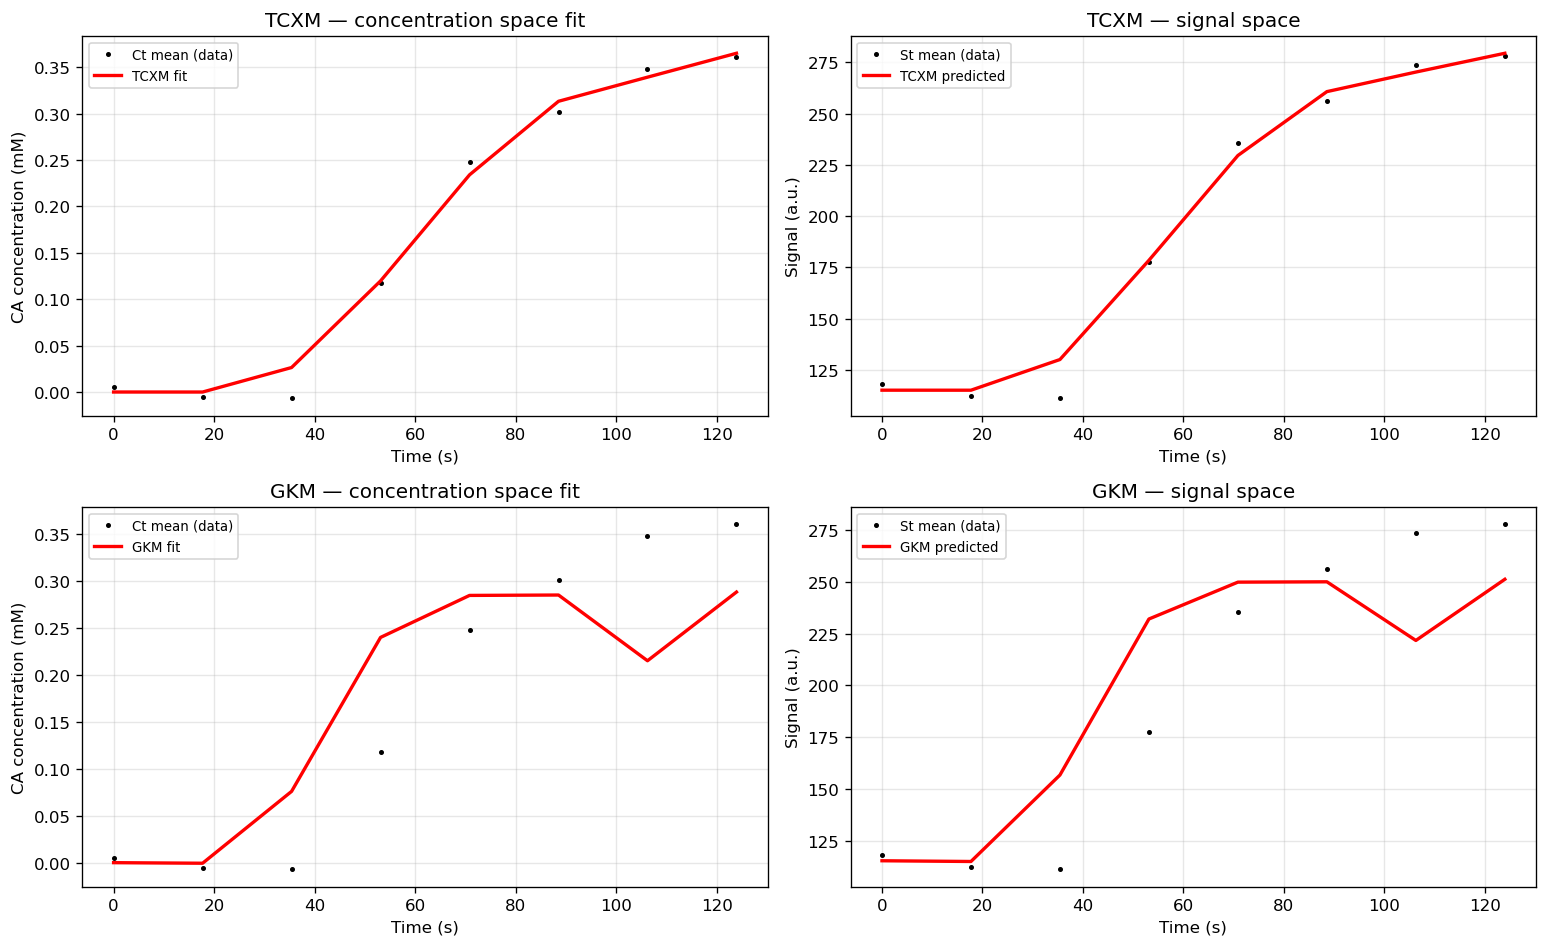

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax_row, result, model, label in zip(
    axes,
    [result_tcxm, result_gkm],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    # concentration fit
    ax_row[0].plot(t, result.Ct_mean, 'k.', ms=4, label='Ct mean (data)')
    ax_row[0].plot(t, result.Ct_pred, 'r-', lw=2, label=f'{label} fit')
    ax_row[0].set_xlabel('Time (s)')
    ax_row[0].set_ylabel('CA concentration (mM)')
    ax_row[0].set_title(f'{label} — concentration space fit')
    ax_row[0].legend(fontsize=8)
    ax_row[0].grid(True, alpha=0.3)

    # signal fit
    ax_row[1].plot(t, result.St_mean, 'k.', ms=4, label='St mean (data)')
    ax_row[1].plot(t, result.St_pred, 'r-', lw=2, label=f'{label} predicted')
    ax_row[1].set_xlabel('Time (s)')
    ax_row[1].set_ylabel('Signal (a.u.)')
    ax_row[1].set_title(f'{label} — signal space')
    ax_row[1].legend(fontsize=8)
    ax_row[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Model fitting with AIF time delay — grid search

In [8]:
# tau grid — adjust range and spacing based on your data
# coarse (fast):  np.arange(-10, 31, 2.0)   — 21 fits
# fine (slower):  np.arange(-10, 31, 1.0)   — 41 fits
tau_values = np.arange(-10, 50, 2.0)

print(f"Grid search over {len(tau_values)} tau values: "
      f"{tau_values[0]:.0f}s to {tau_values[-1]:.0f}s "
      f"(spacing {tau_values[1]-tau_values[0]:.0f}s)")

print("\nFitting TCXM + grid delay ...")
result_tcxm_grid = fit_roi_with_delay_grid(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg,
    tau_values, seed=0
)

print("Fitting GKM + grid delay ...")
result_gkm_grid = fit_roi_with_delay_grid(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg,
    tau_values, seed=0
)

print("\n── TCXM + grid delay ─────────────────────────────")
print(f"  success      : {result_tcxm_grid.success}")
print(f"  cost         : {result_tcxm_grid.best_cost:.4e}")
print(f"  best tau     : {result_tcxm_grid.best_tau:.1f} s")
for name, val in zip(TCXM.param_names, result_tcxm_grid.best_params):
    print(f"  {name:8s}: {val:.5f}")

print("\n── GKM + grid delay ──────────────────────────────")
print(f"  success      : {result_gkm_grid.success}")
print(f"  cost         : {result_gkm_grid.best_cost:.4e}")
print(f"  best tau     : {result_gkm_grid.best_tau:.1f} s")
for name, val in zip(GKM.param_names, result_gkm_grid.best_params):
    print(f"  {name:8s}: {val:.5f}")

Grid search over 30 tau values: -10s to 48s (spacing 2s)

Fitting TCXM + grid delay ...
Fitting GKM + grid delay ...

── TCXM + grid delay ─────────────────────────────
  success      : True
  cost         : 9.8615e-04
  best tau     : 14.0 s
  ve      : 0.50000
  vp      : 0.06921
  fp      : 0.04167
  ps      : 0.00120

── GKM + grid delay ──────────────────────────────
  success      : True
  cost         : 8.7693e-03
  best tau     : 24.0 s
  Ktrans  : 0.03333
  ve      : 0.50000
  vp      : 0.10092


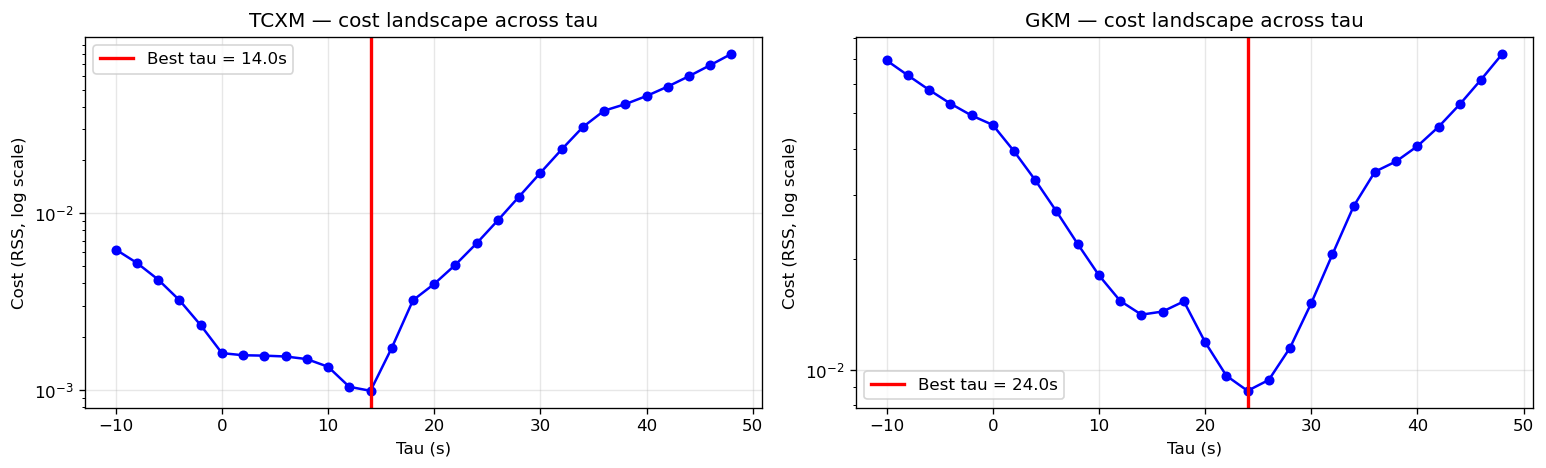

In [9]:
# plot cost landscape across tau values
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, result, model, label in zip(
    axes,
    [result_tcxm_grid, result_gkm_grid],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    taus  = sorted(result.per_tau.keys())
    costs = [result.per_tau[tau].cost for tau in taus]

    ax.semilogy(taus, costs, 'bo-', ms=5, lw=1.5)
    ax.axvline(result.best_tau, color='r', lw=2,
               label=f'Best tau = {result.best_tau:.1f}s')
    ax.set_xlabel('Tau (s)')
    ax.set_ylabel('Cost (RSS, log scale)')
    ax.set_title(f'{label} — cost landscape across tau')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

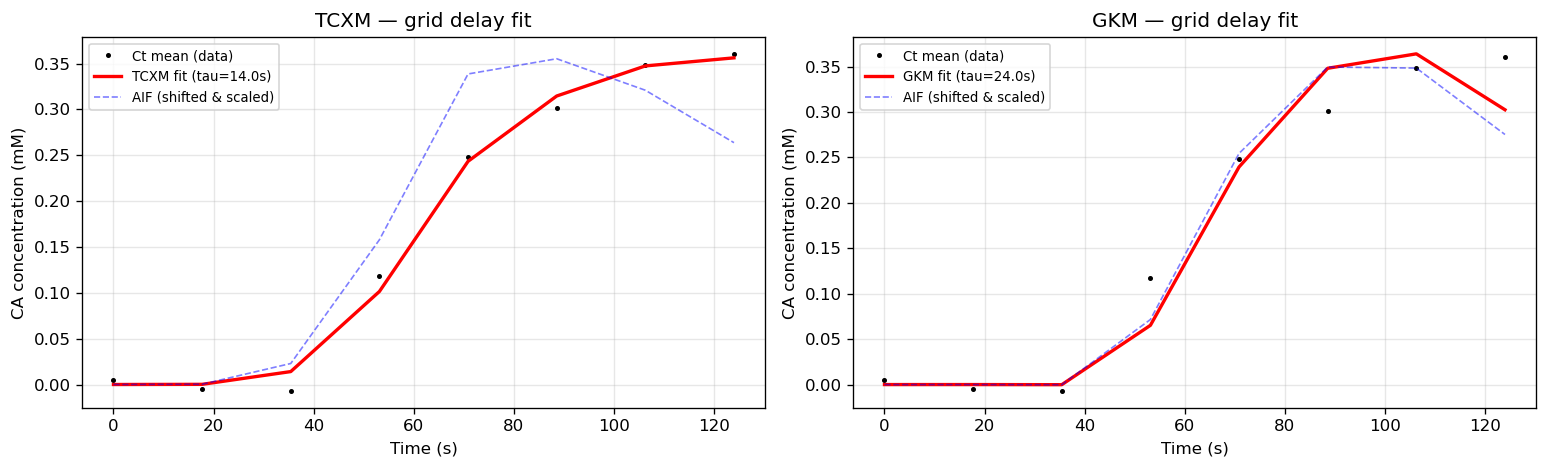

In [10]:
# plot fits at best tau
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

for ax, result, model, label in zip(
    axes,
    [result_tcxm_grid, result_gkm_grid],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    shifted_aif_best = shift_aif(aif, result.best_tau, t, acq)
    Ct_pred_best     = model.fn(result.best_params, t, shifted_aif_best)

    ax.plot(t, Ct_sig_mean,  'k.', ms=4, label='Ct mean (data)')
    ax.plot(t, Ct_pred_best, 'r-', lw=2,
            label=f'{label} fit (tau={result.best_tau:.1f}s)')
    ax.plot(t, shifted_aif_best * Ct_sig_mean.max() / aif.max(),
            'b--', lw=1, alpha=0.5, label='AIF (shifted & scaled)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CA concentration (mM)')
    ax.set_title(f'{label} — grid delay fit')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model fitting with AIF time delay — continuous optimisation

In [11]:
# tau bounds — adjust based on your data and expected delay range
TAU_LB = -10.0   # s
TAU_UB =  50.0   # s
TAU_P0 =   0.0   # s — initial guess

print(f"Continuous tau bounds: [{TAU_LB}, {TAU_UB}] s")

print("\nFitting TCXM + continuous delay ...")
result_tcxm_cont = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg,
    tau_lb=TAU_LB, tau_ub=TAU_UB, tau_p0=TAU_P0, seed=0
)

print("Fitting GKM + continuous delay ...")
result_gkm_cont = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg,
    tau_lb=TAU_LB, tau_ub=TAU_UB, tau_p0=TAU_P0, seed=0
)

print("\n── TCXM + continuous delay ───────────────────────")
print(f"  success      : {result_tcxm_cont.success}")
print(f"  cost         : {result_tcxm_cont.best_cost:.4e}")
print(f"  best tau     : {result_tcxm_cont.best_tau:.3f} s")
for name, val in zip(TCXM.param_names, result_tcxm_cont.best_params):
    print(f"  {name:8s}: {val:.5f}")

print("\n── GKM + continuous delay ────────────────────────")
print(f"  success      : {result_gkm_cont.success}")
print(f"  cost         : {result_gkm_cont.best_cost:.4e}")
print(f"  best tau     : {result_gkm_cont.best_tau:.3f} s")
for name, val in zip(GKM.param_names, result_gkm_cont.best_params):
    print(f"  {name:8s}: {val:.5f}")

Continuous tau bounds: [-10.0, 50.0] s

Fitting TCXM + continuous delay ...
Fitting GKM + continuous delay ...

── TCXM + continuous delay ───────────────────────
  success      : True
  cost         : 9.2498e-04
  best tau     : 13.189 s
  ve      : 0.50000
  vp      : 0.06739
  fp      : 0.04167
  ps      : 0.00122

── GKM + continuous delay ────────────────────────
  success      : True
  cost         : 8.7645e-03
  best tau     : 24.158 s
  Ktrans  : 0.03333
  ve      : 0.50000
  vp      : 0.10107


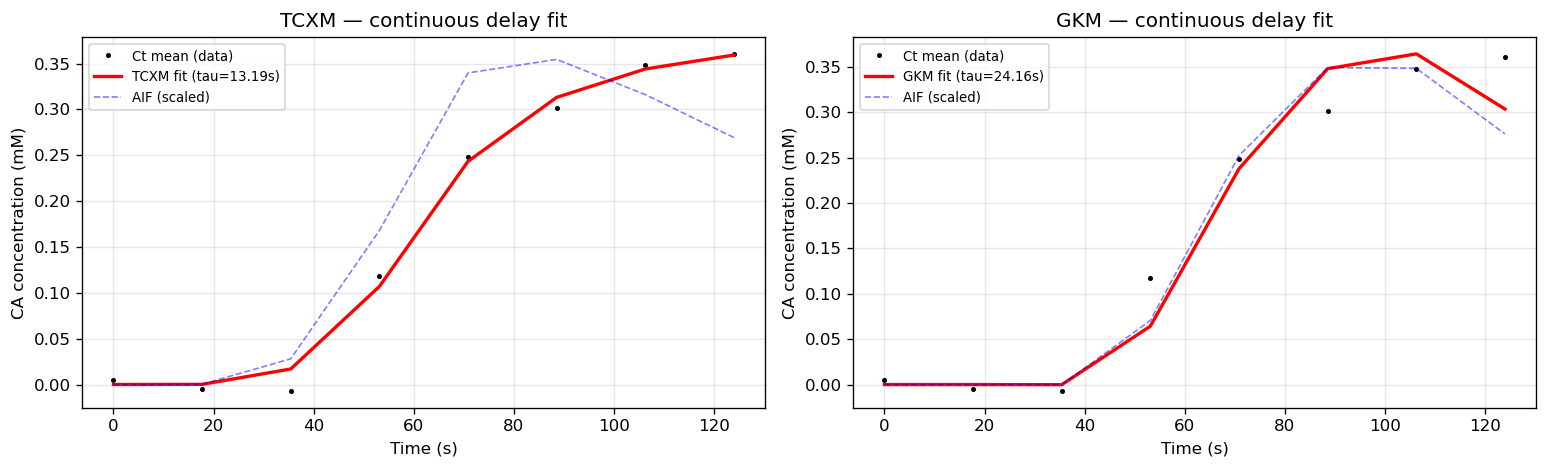

In [12]:
# plot continuous delay fits
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

for ax, result, model, label in zip(
    axes,
    [result_tcxm_cont, result_gkm_cont],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    shifted_aif_best = shift_aif(aif, result.best_tau, t, acq)
    Ct_pred_best     = model.fn(result.best_params, t, shifted_aif_best)

    ax.plot(t, Ct_sig_mean,  'k.', ms=4, label='Ct mean (data)')
    ax.plot(t, Ct_pred_best, 'r-', lw=2,
            label=f'{label} fit (tau={result.best_tau:.2f}s)')
    ax.plot(t, shifted_aif_best * Ct_sig_mean.max() / aif.max(),
            'b--', lw=1, alpha=0.5, label='AIF (scaled)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CA concentration (mM)')
    ax.set_title(f'{label} — continuous delay fit')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Cost comparison — no delay vs grid vs continuous

In [13]:
# summary table
print(f"{'Method':<30} {'Model':<8} {'Cost':>12} {'Tau (s)':>10} {'Success'}")
print("-" * 70)

rows = [
    ("No delay",         "TCXM", result_tcxm.cost,           None,                         result_tcxm.success),
    ("No delay",         "GKM",  result_gkm.cost,            None,                         result_gkm.success),
    ("Grid delay",       "TCXM", result_tcxm_grid.best_cost, result_tcxm_grid.best_tau,    result_tcxm_grid.success),
    ("Grid delay",       "GKM",  result_gkm_grid.best_cost,  result_gkm_grid.best_tau,     result_gkm_grid.success),
    ("Continuous delay", "TCXM", result_tcxm_cont.best_cost, result_tcxm_cont.best_tau,    result_tcxm_cont.success),
    ("Continuous delay", "GKM",  result_gkm_cont.best_cost,  result_gkm_cont.best_tau,     result_gkm_cont.success),
]

for method, model, cost, tau, success in rows:
    tau_str = f"{tau:.2f}" if tau is not None else "—"
    print(f"{method:<30} {model:<8} {cost:>12.4e} {tau_str:>10} {success}")

Method                         Model            Cost    Tau (s) Success
----------------------------------------------------------------------
No delay                       TCXM       1.6125e-03          — True
No delay                       GKM        4.6396e-02          — True
Grid delay                     TCXM       9.8615e-04      14.00 True
Grid delay                     GKM        8.7693e-03      24.00 True
Continuous delay               TCXM       9.2498e-04      13.19 True
Continuous delay               GKM        8.7645e-03      24.16 True


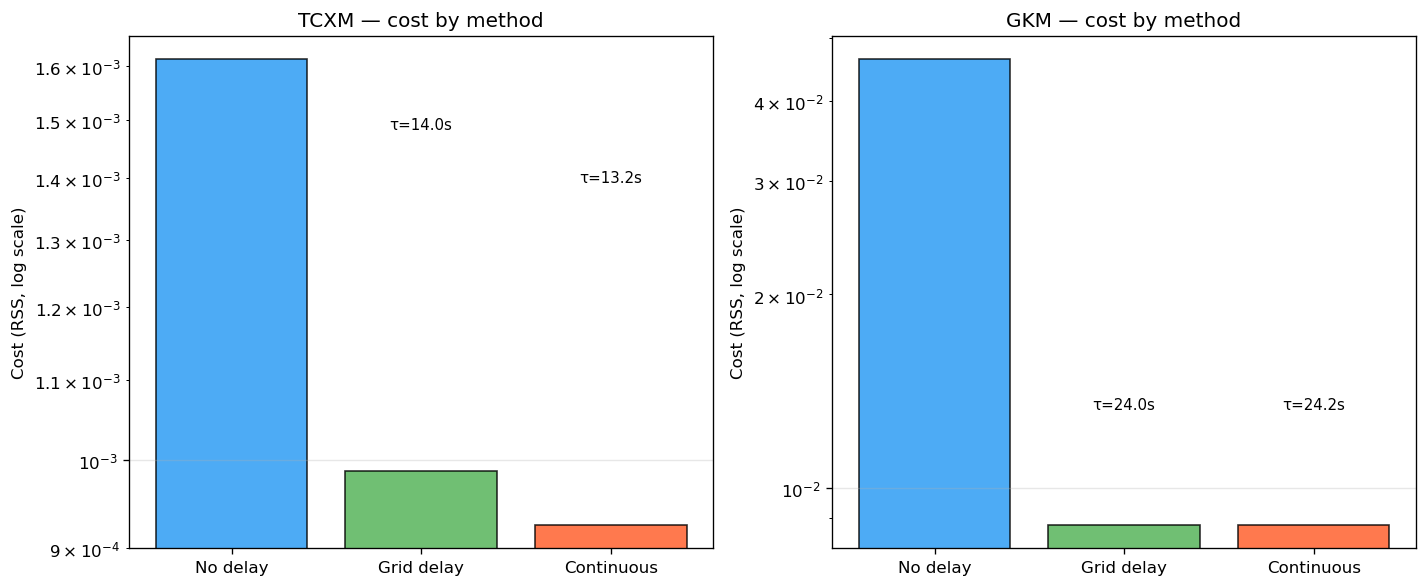

In [14]:
# bar chart of costs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ['No delay', 'Grid delay', 'Continuous']

for ax, model_label, costs_list, tau_list in zip(
    axes,
    ['TCXM', 'GKM'],
    [
        [result_tcxm.cost,
         result_tcxm_grid.best_cost,
         result_tcxm_cont.best_cost],
        [result_gkm.cost,
         result_gkm_grid.best_cost,
         result_gkm_cont.best_cost],
    ],
    [
        [None,
         result_tcxm_grid.best_tau,
         result_tcxm_cont.best_tau],
        [None,
         result_gkm_grid.best_tau,
         result_gkm_cont.best_tau],
    ],
):
    bars = ax.bar(methods, costs_list,
                  color=['#2196F3', '#4CAF50', '#FF5722'],
                  alpha=0.8, edgecolor='black')
    ax.set_yscale('log')
    ax.set_ylabel('Cost (RSS, log scale)')
    ax.set_title(f'{model_label} — cost by method')
    ax.grid(True, alpha=0.3, axis='y')

    # annotate bars with tau value
    for bar, tau in zip(bars, tau_list):
        if tau is not None:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.5,
                    f'τ={tau:.1f}s',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

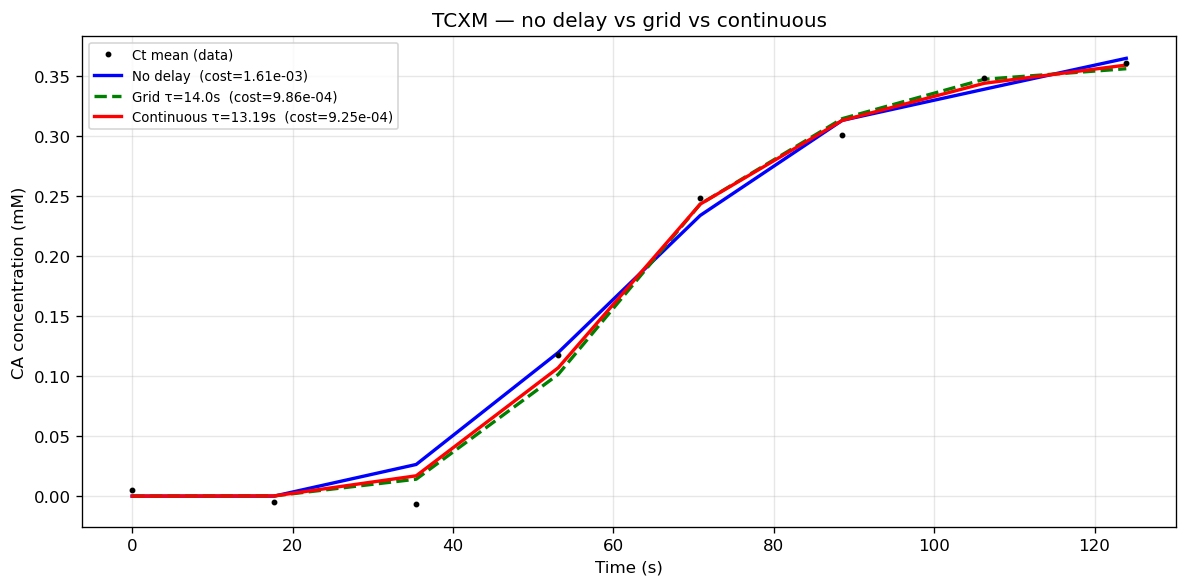

[1.06887423e-07 1.84174796e-04 1.40960702e-02 1.01441841e-01
 2.43408004e-01 3.14624990e-01 3.47436256e-01 3.56255786e-01]


In [15]:
# overlay all fits on one plot for TCXM
Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

Ct_nodelay = TCXM.fn(result_tcxm.params, t, aif)
Ct_grid    = TCXM.fn(result_tcxm_grid.best_params, t,
                      shift_aif(aif, result_tcxm_grid.best_tau, t, acq))
Ct_cont    = TCXM.fn(result_tcxm_cont.best_params, t,
                      shift_aif(aif, result_tcxm_cont.best_tau, t, acq))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, Ct_sig_mean, 'k.', ms=5, zorder=5, label='Ct mean (data)')
ax.plot(t, Ct_nodelay,  'b-',  lw=2, label=f'No delay  (cost={result_tcxm.cost:.2e})')
ax.plot(t, Ct_grid,     'g--', lw=2,
        label=f'Grid τ={result_tcxm_grid.best_tau:.1f}s  '
              f'(cost={result_tcxm_grid.best_cost:.2e})')
ax.plot(t, Ct_cont,     'r-',  lw=2,
        label=f'Continuous τ={result_tcxm_cont.best_tau:.2f}s  '
              f'(cost={result_tcxm_cont.best_cost:.2e})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('CA concentration (mM)')
ax.set_title('TCXM — no delay vs grid vs continuous')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(Ct_grid)

In [16]:
result_tcxm_pchip = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg,
    tau_lb=-10.0, tau_ub=50.0, tau_p0=0.0, seed=0,
    interp_method="pchip"
)
result_gkm_pchip = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg,
    tau_lb=-10.0, tau_ub=50.0, tau_p0=0.0, seed=0,
    interp_method="pchip"
)

print(f"TCXM linear: tau={result_tcxm_cont.best_tau:.2f}s  cost={result_tcxm_cont.best_cost:.4e}")
print(f"TCXM pchip:  tau={result_tcxm_pchip.best_tau:.2f}s  cost={result_tcxm_pchip.best_cost:.4e}")
print(f"GKM linear:  tau={result_gkm_cont.best_tau:.2f}s  cost={result_gkm_cont.best_cost:.4e}")
print(f"GKM pchip:   tau={result_gkm_pchip.best_tau:.2f}s  cost={result_gkm_pchip.best_cost:.4e}")

TCXM linear: tau=13.19s  cost=9.2498e-04
TCXM pchip:  tau=11.68s  cost=5.6390e-04
GKM linear:  tau=24.16s  cost=8.7645e-03
GKM pchip:   tau=24.68s  cost=1.1853e-02


## 8. Multi-ROI fitting

In [17]:
# fit one model per segmentation label
# for synthetic data seg_vol has only label=1
# for real data replace seg_vol with your segmentation volume

print("Fitting TCXM to all ROI labels ...")
multi_results = fit_multi_roi(
    sig_4d, seg_vol, aif, t, TCXM, acq, subject, cfg, roi_cfg, seed=0
)

print(f"\n{'Label':<8} {'n_vox':<8} {'success':<10} "
      f"{'cost':>10}  "
      + '  '.join(f"{n:>8}" for n in TCXM.param_names))
print("-" * 70)

for label, res in sorted(multi_results.items()):
    param_str = '  '.join(f"{v:>8.5f}" for v in res.params)
    print(f"{label:<8} {res.n_voxels:<8} {str(res.success):<10} "
          f"{res.cost:>10.4e}  {param_str}")

Fitting TCXM to all ROI labels ...


NameError: name 'seg_vol' is not defined

In [ ]:
# plot multi-ROI fits
n_labels = len(multi_results)
fig, axes = plt.subplots(1, max(n_labels, 1), figsize=(6 * n_labels, 4),
                          squeeze=False)

colors = plt.cm.tab10.colors
for idx, (label, res) in enumerate(sorted(multi_results.items())):
    ax = axes[0, idx]
    ax.plot(t, res.Ct_mean, 'k.', ms=4, label='Ct mean')
    ax.plot(t, res.Ct_pred, '-',  lw=2,
            color=colors[idx % len(colors)],
            label=f'TCXM fit')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CA concentration (mM)')
    ax.set_title(f'ROI label {label} ({res.n_voxels} voxels)\n'
                 + ', '.join(f'{n}={v:.4f}'
                             for n, v in zip(TCXM.param_names, res.params)))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()